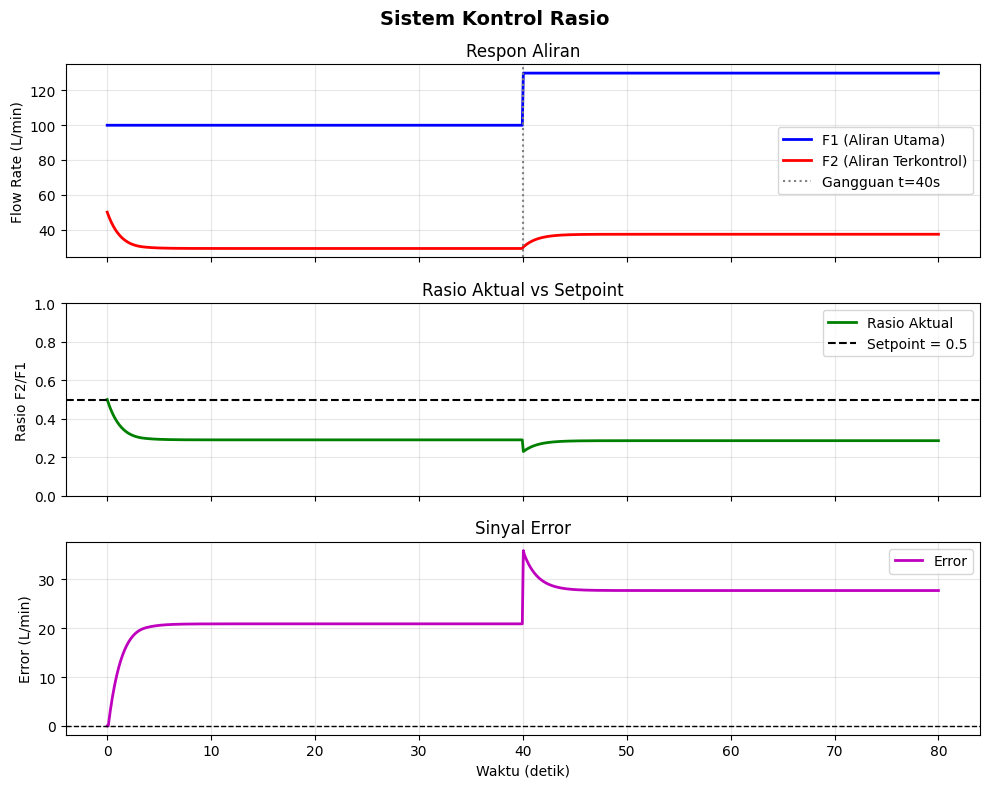


===== ANALISIS SISTEM KONTROL RASIO =====
Setpoint Rasio       : 0.5
Rasio Steady State   : 0.2867
Error Steady State   : 27.7273 L/min
Overshoot            : 0.00%
Sistem               : TIDAK STABIL ✗


In [1]:
"""
SISTEM KONTROL RASIO (Ratio Control System)
============================================
Mengontrol rasio dua aliran agar tetap konstan (F2/F1 = 0.5)
Contoh: pencampuran bahan kimia A dan B dengan rasio tertentu
"""

import numpy as np
import matplotlib.pyplot as plt

# ─── Parameter ───────────────────────────────────────────────────────────────
rasio_set  = 0.5
Kp, Ki, Kd = 1.2, 0.08, 0.05
tau        = 3.0

# ─── Waktu ───────────────────────────────────────────────────────────────────
t  = np.linspace(0, 80, 800)
dt = t[1] - t[0]

# ─── Aliran utama F1 (gangguan di t=40) ──────────────────────────────────────
F1 = np.where(t < 40, 100.0, 130.0)

# ─── Variabel ────────────────────────────────────────────────────────────────
F2        = np.zeros(len(t)); F2[0] = rasio_set * F1[0]
rasio_act = np.zeros(len(t)); rasio_act[0] = rasio_set
error     = np.zeros(len(t))
integral  = 0.0
prev_err  = 0.0

# ─── Simulasi PID ────────────────────────────────────────────────────────────
for i in range(1, len(t)):
    SP       = rasio_set * F1[i]
    error[i] = SP - F2[i-1]
    integral += error[i] * dt
    integral  = np.clip(integral, -50, 50)
    deriv     = (error[i] - prev_err) / dt
    u         = np.clip(Kp*error[i] + Ki*integral + Kd*deriv, 0, 200)
    prev_err  = error[i]

    dF2    = (-F2[i-1] + u) / tau
    F2[i]  = max(0, F2[i-1] + dF2 * dt)
    rasio_act[i] = F2[i] / F1[i]

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Sistem Kontrol Rasio", fontsize=14, fontweight="bold")

axes[0].plot(t, F1, "b-", label="F1 (Aliran Utama)", lw=2)
axes[0].plot(t, F2, "r-", label="F2 (Aliran Terkontrol)", lw=2)
axes[0].axvline(40, color="gray", ls=":", label="Gangguan t=40s")
axes[0].set_ylabel("Flow Rate (L/min)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Respon Aliran")

axes[1].plot(t, rasio_act, "g-", label="Rasio Aktual", lw=2)
axes[1].axhline(rasio_set, color="k", ls="--", label=f"Setpoint = {rasio_set}", lw=1.5)
axes[1].set_ylabel("Rasio F2/F1"); axes[1].set_ylim([0, 1])
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Rasio Aktual vs Setpoint")

axes[2].plot(t, error, "m-", label="Error", lw=2)
axes[2].axhline(0, color="k", ls="--", lw=1)
axes[2].set_ylabel("Error (L/min)"); axes[2].set_xlabel("Waktu (detik)")
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title("Sinyal Error")

plt.tight_layout()
plt.savefig("hasil_rasio.png", dpi=150, bbox_inches="tight")
plt.show()

# ─── Analisis ────────────────────────────────────────────────────────────────
ss_error  = abs(error[-1])
overshoot = max(0, rasio_act.max() - rasio_set) / rasio_set * 100

print("\n===== ANALISIS SISTEM KONTROL RASIO =====")
print(f"Setpoint Rasio       : {rasio_set}")
print(f"Rasio Steady State   : {rasio_act[-1]:.4f}")
print(f"Error Steady State   : {ss_error:.4f} L/min")
print(f"Overshoot            : {overshoot:.2f}%")
print(f"Sistem               : {'STABIL ✓' if ss_error < 1.0 else 'TIDAK STABIL ✗'}")